In [39]:
from __future__ import annotations
import os, json, operator, requests, psutil, wikipedia
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage
from langchain_core.tools import tool, Tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.vectorstores import FAISS


In [40]:
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
NEWSAPI_API_KEY = os.getenv("News_API_KEY")
OPENWEATHER_API_KEY = os.getenv("Weather_API_KEY")
MODEL_NAME = "gpt-4o-mini"

SandBox for Controlled and Isolated Environment

In [ ]:

SANDBOX_DIR = os.path.abspath("./bitty_sandbox")
RAG_DIR = os.path.abspath("./rag_docs")
INDEX_PATH = os.path.abspath("./rag_index")

os.makedirs(SANDBOX_DIR, exist_ok=True)
os.makedirs(RAG_DIR, exist_ok=True)
os.makedirs(INDEX_PATH, exist_ok=True)



Tools Defining

In [43]:
# @tool(name="cpu_monitor", description="Report CPU and memory utilization in percent.")
def cpu_monitor_tool(_: str = "") -> str:
    cpu = psutil.cpu_percent(interval=0.7)
    mem = psutil.virtual_memory().percent
    return f"CPU usage: {cpu:.1f}%, Memory usage: {mem:.1f}%."

cpu_monitor = Tool(
    name = "cpu_monitor",
    description = "Report CPU and memory utilization in percent.",
    func = cpu_monitor_tool,
)

# @tool(name="safe_delete", description="Delete a file under sandbox. Input is relative path under jarvis_sandbox.")
def safe_delete_tool(rel_path: str) -> str:
    if not rel_path:
        return "Provide a relative path under sandbox (e.g., notes/todo.txt)."

    abs_path = os.path.abspath(os.path.join(SANDBOX_DIR, rel_path))

    if not abs_path.startswith(SANDBOX_DIR):
        return "Refused: path escapes sandbox."

    if not os.path.exists(abs_path):
        return f"File not found: {rel_path}"

    try:
        os.remove(abs_path)
        return f"Deleted: {rel_path}"

    except Exception as e:
        return f"Failed to delete {rel_path}: {e}"

safe_delete = Tool(
    name = "safe_delete",
    func = safe_delete_tool,
    description = "Delete a file under sandbox. Input is relative path under jarvis_sandbox."
)

# @tool(name="news_tool", description="Top headlines via NewsAPI for a country code (us, gb, pk, etc.).")
def news_tool_tool(country_code: str = "us") -> str:
    if not NEWSAPI_API_KEY :
        return "NewsAPI key missing."

    url = "https://newsapi.org/v2/top-headlines"
    params = {"country": country_code, "apiKey": NEWSAPI_API_KEY, "pageSize": 5}
    data = requests.get(url, params=params, timeout=10).json()
    if data.get("status") != "ok":
        return f"NewsAPI error: {data}"
    titles = [a["title"] for a in data.get("articles", [])]
    return "Top headlines:\n- " + "\n- ".join(titles) if titles else "No headlines."

news_tool = Tool(
    name ="news_tool",
    func = news_tool_tool,  
    description="Top headlines via NewsAPI for a country code (us, gb, pk, etc.).",
)


# @tool(name="weather_tool", description="Current weather for a city using OpenWeather (metric).")
def weather_tool_tool(city: str = "Karachi") -> str:
    if not OPENWEATHER_API_KEY:
        return "OpenWeather key missing."
        
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": OPENWEATHER_API_KEY, "units": "metric"}
    data = requests.get(url, params=params, timeout=10).json()
    if "main" not in data:
        return f"Weather error: {data.get('message', data)}"
    temp = data["main"]["temp"]
    desc = data["weather"][0]["description"]
    return f"Weather in {city}: {temp}°C, {desc}."

weather_tool = Tool(
    name="weather_tool", 
    description="Current weather for a city using OpenWeather (metric).",
    func = weather_tool_tool, 
)

# @tool(name="wiki_tool", description="Search Wikipedia for information.")
def wiki_tool_tool(query: str) -> str:
    try:
        # Search for the page
        search_results = wikipedia.search(query, results=1)
        if not search_results:
            return f"No Wikipedia articles found for '{query}'"
        
        # Get the page summary
        page = wikipedia.page(search_results[0])
        summary = wikipedia.summary(search_results[0], sentences=3)
        return f"Wikipedia result for '{query}':\n{summary}\n\nFull article: {page.url}"
    except wikipedia.exceptions.DisambiguationError as e:
        return f"Multiple matches found for '{query}'. Please be more specific."

    except wikipedia.exceptions.PageError:
        return f"No Wikipedia page found for '{query}'"
        
    except Exception as e:
        return f"Wikipedia search failed: {e}"

wiki_tool = Tool(
    name="wiki_tool",
    description="Search Wikipedia for information.",
    func = wiki_tool_tool
)

This Block has RAG Tools

In [44]:
def build_rag_index() -> str:

    docs = []

    for name in os.listdir(RAG_DIR):
        path = os.path.join(RAG_DIR, name)

        if os.path.isfile(path) and any(name.lower().endswith(ext) for ext in [".txt", ".md"]):
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()
            chunks = [text[i:i+1500] for i in range(0, len(text), 1500)]
            for idx, chunk in enumerate(chunks):
                docs.append({"page_content": chunk, "metadata": {"source": name, "chunk": idx}})

    if not docs:
        return "No text files found in rag_docs."

    embeddings = OpenAIEmbeddings()
    vs = FAISS.from_texts([d["page_content"] for d in docs], embedding=embeddings, metadatas=[d["metadata"] for d in docs])
    vs.save_local(INDEX_PATH)
    return f"RAG index built with {len(docs)} chunks."

def load_vectorstore():
    embeddings = OpenAIEmbeddings()
    return FAISS.load_local(INDEX_PATH, embeddings, allow_dangerous_deserialization=True)

# @tool(name="rag_search", description="Semantic search over local docs. Input: query string.")
def rag_search_tool(query: str) -> str:
    vs = load_vectorstore()
    docs = vs.similarity_search(query, k=3)
    lines = []
    for d in docs:
        meta = d.metadata or {}
        src = meta.get("source","?"); ch = meta.get("chunk","?")
        lines.append(f"- ({src}#chunk{ch}) {d.page_content[:300]}...")
        
    return "RAG results:\n" + "\n".join(lines) if lines else "No similar chunks found."

rag_search = Tool(
    name = "rag_search", 
    description = "Semantic search over local docs. Input: query string.",
    func = rag_search_tool
)

State that passes from node to node

In [45]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    tool_calls: Annotated[list[str], operator.add]
    memory: dict
    scratchpad: str


This Block has Persistent Memory

In [ ]:

MEMORY_FILE = os.path.join(SANDBOX_DIR, "memory.json")

def load_memory() -> dict:
    if os.path.exists(MEMORY_FILE):
        try:
            return json.load(open(MEMORY_FILE,"r", encoding="utf-8"))
        except: return {}
    return {}

def save_memory(mem: dict) -> None:
    with open(MEMORY_FILE,"w",encoding="utf-8") as f:
        json.dump(mem, f, ensure_ascii = False, indent = 2)

# @tool(name="remember", description="Store key=value fact. Input: key::value")
def remember_tool(kv: str) -> str:
    if "::" not in kv: return "Use key::value format."
    key,value = [x.strip() for x in kv.split("::",1)]
    mem = load_memory(); mem[key]=value; save_memory(mem)
    return f"Remembered {key}."

remember = Tool(
    name="remember",
    description="Store key=value fact. Input: key::value",
    func = remember_tool
)

# @tool(name="recall", description="Retrieve fact by key")
def recall_tool(key: str) -> str:
    mem = load_memory(); return f"{key} = {mem[key]}" if key in mem else f"No value found for {key}."

recall = Tool(
    name = "recall", 
    description = "Retrieve fact by key",
    func = recall_tool
)

This Block is for Structured Router

In [47]:
class RouteDecision(BaseModel):
    action: Literal["answer","tool:cpu_monitor","tool:safe_delete","tool:news_tool","tool:weather_tool","tool:wiki_tool","tool:rag_search","confirm_delete"]
    argument: str = Field("", description = "Argument for the chosen action/tool")

llm = ChatOpenAI(
    model = MODEL_NAME,
    api_key = OPENAI_API_KEY,
    temperature=0.6,
    )

structured_llm = llm.with_structured_output(RouteDecision)

SYSTEM_ROUTER = SystemMessage(content=(
    "You are Bitty's router/Brain. Tools: cpu_monitor, safe_delete, news_tool, weather_tool, wiki_tool, rag_search.\n"
    "For file deletions: NEVER call safe_delete directly. Instead set action='confirm_delete' with arg=relative path.\n"
    "If info missing, ask clarification with action='answer'."
))

def llm_router(state: AgentState) -> AgentState:

    convo = [SYSTEM_ROUTER] + state["messages"]
    decision: RouteDecision = structured_llm.invoke(convo)
    note=f"ROUTER -> {decision.action} | arg={decision.argument}"
    
    return {"messages":[AIMessage(content=note)],"tool_calls":[decision.action],
            "memory":state.get("memory",{}),"scratchpad":state.get("scratchpad","")}

This is Human in the Loop

In [48]:
def confirmation_node(state: AgentState) -> AgentState:

    last_ai = state["messages"][-1].content if state.get("messages") else ""
    arg = last_ai.split("| arg=",1)[-1] if "| arg=" in last_ai else ""
    mem = load_memory(); mem["pending_delete"] = arg; save_memory(mem)
    prompt=f"Are you sure you want to delete '{arg}' from sandbox? Reply YES or NO."
    
    return {"messages":[AIMessage(content=prompt)],"tool_calls":[],"memory":mem,"scratchpad":state.get("scratchpad","")}

Binding Tools

In [49]:
TOOLS_BY_NAME={"cpu_monitor":cpu_monitor_tool,"safe_delete":safe_delete_tool,
               "news_tool":news_tool_tool,"weather_tool":weather_tool_tool,
               "wiki_tool":wikipedia.summary,"rag_search":rag_search_tool,
               "remember":remember_tool,"recall":recall_tool}

This Block Dispatches Concerning Tool

In [ ]:
def tool_dispatcher(state: AgentState) -> AgentState:

    if not state.get("tool_calls"): 
        return {"messages":[], "tool_calls":[],"memory":state.get("memory",{}),"scratchpad":state.get("scratchpad","")}

    decision = state["tool_calls"][-1]

    if not decision.startswith("tool:"):
        return {"messages":[], "tool_calls":[],"memory":state.get("memory",{}),"scratchpad":state.get("scratchpad","")}
    
    tool_name = decision.split("tool:",1)[-1]

    tool_fn = TOOLS_BY_NAME.get(tool_name)

    last_ai = state["messages"][-1].content if state.get("messages") else ""

    argument = last_ai.split("| arg=",1)[-1] if "| arg=" in last_ai else ""

    try: 
        result = tool_fn(argument)
        
    except Exception as e: 
        result = f"Tool `{tool_name}` failed: {e}"
        
    return {"messages":[AIMessage(content=f"[{tool_name}]: {result}")],"tool_calls":[],"memory":state.get("memory",{}),"scratchpad":state.get("scratchpad","")}

This Block Passes the final output

In [51]:
def final_answer(state: AgentState) -> AgentState:

    last_assistant = None

    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            last_assistant = msg
            break

    content = last_assistant.content if last_assistant else "Done."
    
    return {"messages":[AIMessage(content=content)],"tool_calls":[],"memory":state.get("memory",{}),"scratchpad":state.get("scratchpad","")}

Building Graph

In [52]:
def route_decision(state: AgentState)->Literal["to_tool","to_answer","to_confirm"]:
    if not state.get("tool_calls"):
         return "to_answer"

    last = state["tool_calls"][-1]

    if last == "confirm_delete": return "to_confirm"

    return "to_tool" if last.startswith("tool:") else "to_answer"

graph = StateGraph(AgentState)

graph.add_node("llm_router",llm_router)
graph.add_node("confirmation",confirmation_node)
graph.add_node("tool_dispatcher",tool_dispatcher)
graph.add_node("final_answer",final_answer)

graph.set_entry_point("llm_router")

graph.add_conditional_edges(
    "llm_router",
    route_decision,{
        "to_tool":"tool_dispatcher",
        "to_answer":"final_answer",
        "to_confirm":"confirmation"
        }
    )

graph.add_edge("confirmation","final_answer")
graph.add_edge("tool_dispatcher","llm_router")
graph.add_edge("final_answer",END)

app = graph.compile(checkpointer=MemorySaver())

print("Pro Graph compiled.")

Pro Graph compiled.


This Block shows the graph visually

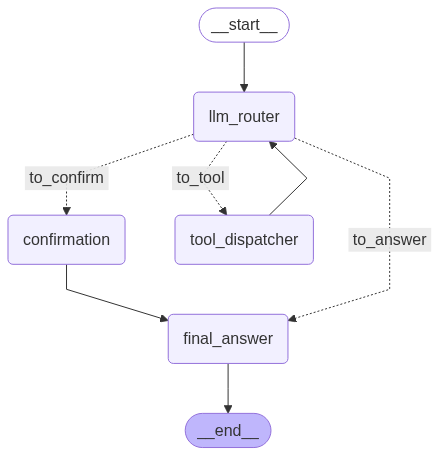

In [53]:
#to show the graph only in Jupyter environment
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
    
except ImportError:
    print("Graph visualization skipped (IPython not available in this environment)")
    # Alternative: save graph as image file
    try:
        import graphviz
        app.get_graph().draw_mermaid_png("Bitty_graph.png")
        print("Graph saved as 'Bitty_graph.png'")
    except:
        print("Graph visualization not available")

This Block is The Runner

In [ ]:
def run_bitty(user_text:str, thread_id:str = "demo") -> str:
    
    mem = load_memory()
    state = {"messages":[HumanMessage(content=user_text)],"tool_calls":[],"memory":mem,"scratchpad":""}
    output = app.invoke(
        state,
        config={"recursion_limit":10000, "configurable":{"thread_id":thread_id}})
    
    save_memory(output.get("memory", mem))

    final = None
    for m in reversed(output["messages"]):
        if isinstance(m, AIMessage): 
            final = m
            break
        
    word_to_find = "arg"
    
    if word_to_find in final.content:
        
        index = final.content.find(word_to_find)
        return final.content[index + len(word_to_find) + 1:].strip()

    else:
        # return " "
        return final.content if final else "exit"

This Block is for T.T.S.

In [55]:
# import pyttsx3

# def speak(text):
#     engine = pyttsx3.init()
#     engine.say(text)
#     engine.runAndWait()
#     engine.stop()






import os
import time
import tempfile
from gtts import gTTS
import playsound

def speak(text, lang="ur"):
    # Create a real temp filename, then CLOSE the OS handle 
    fd, path = tempfile.mkstemp(suffix=".mp3")
    os.close(fd)

    try:
        # Save TTS to the temp file
        tts = gTTS(text=text, lang=lang, slow=False)
        tts.save(path)  # path must be a STRING

        # Play(blocks until finished)
        playsound.playsound(path)

    finally:
        # Retry deletion a few times in case Windows still holds a lock briefly
        for _ in range(10):
            try:
                os.remove(path)
                break
            except PermissionError:
                time.sleep(0.2)  # tiny delay then try again
            except FileNotFoundError:
                break



This Block takes input in form of voice

In [56]:
import speech_recognition as sr


def listen_command(prompt="Listening...", timeout=10, phrase_time_limit=20):
    """Helper to listen once and return recognized text"""
    recognizer = sr.Recognizer()
    mic = sr.Microphone()

    with mic as source:

        recognizer.adjust_for_ambient_noise(source)
        print(prompt)

        try:

            audio = recognizer.listen(source, timeout=timeout, phrase_time_limit=phrase_time_limit)
            text = recognizer.recognize_google(audio)
            print("Heard:", text)
            return text.lower()

        except sr.UnknownValueError:

            print("Could not understand audio")
            return ""

        except sr.RequestError:

            print("Error: check your internet connection.")
            return ""

        except sr.WaitTimeoutError:

            print("Error: Wait Time Out Error Occured")
            return ""

This Block ensures Awake Word, TineOut, and Functions to run smoothly 

In [57]:
import time, sys
def listen_for_wake_word(wake_word="wake up", active_timeout=15):
    """Wake word once → stay active for commands → sleep after timeout"""
    active_mode = False
    last_command_time = 0

    while True:
        if not active_mode:
            # Waiting for wake word
            speak(f"Bitty Started. Proceed to Activate........")
            text = listen_command(f"Bitty Started. Proceed to Activate:  '{wake_word}'...")
            if wake_word in text:
                speak("          Yes What Can I do for You?")
                active_mode = True
                last_command_time = time.time()
        else:
            # Already awake, listen for commands
            while True:
                command = listen_command("Listening for your command...")
                
                last_command_time = time.time()
                print(command)

                checking = run_bitty(command)
                print(checking)
                speak(checking)

                if  checking == "exit":
                    print("GoodBye")
                    break
                    #sys.exit("Exiting as User asked")
            

            else:
                
                # No command heard: check if timeout expired
                if time.time() - last_command_time > active_timeout:
                    print("Going back to sleep, say Bitty to wake me up again")
                    speak("Going back to sleep, say Bitty to wake me up again.")
                    break
                    active_mode = False


This __name__ thing lets you run code only if its executed in main file

In [59]:
if __name__=="__main__":
    
    os.makedirs(os.path.join(SANDBOX_DIR,"notes"),exist_ok = True)
    with open(os.path.join(SANDBOX_DIR,"notes","todo.txt"),"w") as f: 
        f.write("temporary note")
    
    listen_for_wake_word("wake up")
    
    
    
    #   print(run_jarvis("lahore ka weather kesa hai"))
    # # print(run_jarvis("Remember default_city::Karachi"))
    # # print(run_jarvis("Recall default_city"))
    # # print(build_rag_index())  # build once
    # # print(run_jarvis("Search LangGraph"))
    # # print(run_jarvis("Delete notes/todo.txt"))  # will ask confirmation
    # # print(run_jarvis("YES"))  # confirm deletion

Bitty Started. Proceed to Activate:  'wake up'...
Heard: wake up
Listening for your command...
Heard: remember my name
remember my name
I currently don't have the capability to remember personal information like names. However, I can assist you with various tasks whenever you need!
Listening for your command...
Heard: what was my previous question to you
what was my previous question to you
Your previous question was asking me to remember your name.
Listening for your command...
Heard: remember that my birthday is on 13th May
remember that my birthday is on 13th may
I currently don't have the capability to remember personal information like birthdays. However, you can remind me whenever you need assistance!
Listening for your command...
Heard: ok make a rack search and give me a summary of the document that you have in black
ok make a rack search and give me a summary of the document that you have in black
I encountered an issue while trying to perform the search. It seems that the nec

KeyboardInterrupt: 